# Tema Analisi esplorativa: dataset penguins

In [1]:
import seaborn as sns
import pandas as pd

Importiamo tramite la libreria seaborn il dataset penguins 

Citazione: Gorman KB, Williams TD, Fraser WR (2014) Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis). PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081

In [2]:
penguins = sns.load_dataset("penguins")

Spiegazione delle variabili
- species -> variabile target contente la specie del pinguino
- island -> nome dell'isola
- bill length -> lunghezza becco
- bill_depth -> profondità becco
- flipper length -> lunghezza pinna
- body mass -> massa corporea
- sex -> sesso

In [3]:
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


Iniziamo a ottenere informazione sui tipi e sul numero di null

In [4]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


e sulla statistica monovariata di base

In [5]:
penguins.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


Ora continua tu! 

Puoi svolgere l'analisi esplorativa liberamente o seguire i titoli dei prossimi paragrafi. Per ogni sezione crea i grafici o effettua i calcoli che ritieni più opportuni e aggiungi sempre una conclusione alla fine.

## Iniziamo a studiare la distribuzione della variabile target species

In [38]:
penguins.groupby(by="species").size()

species
Adelie       152
Chinstrap     68
Gentoo       124
dtype: int64

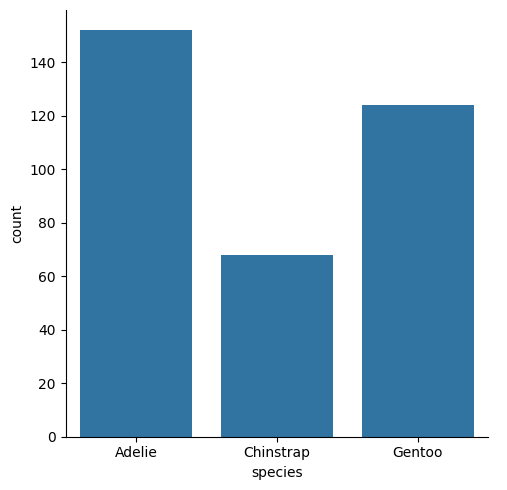

In [7]:
g = sns.catplot(data=penguins, x="species", kind="count")

In [8]:
penguins["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [16]:
len(penguins["species"].notna()), len(penguins["species"])

(344, 344)

<b>Conclusioni</b>: La feature target 'species' è una variabile nominale con 3 possibili valori, non distribuiti uniformemente e nessun null


## Rappresentare con un opportuno grafico le relazioni tra le variabili species e island

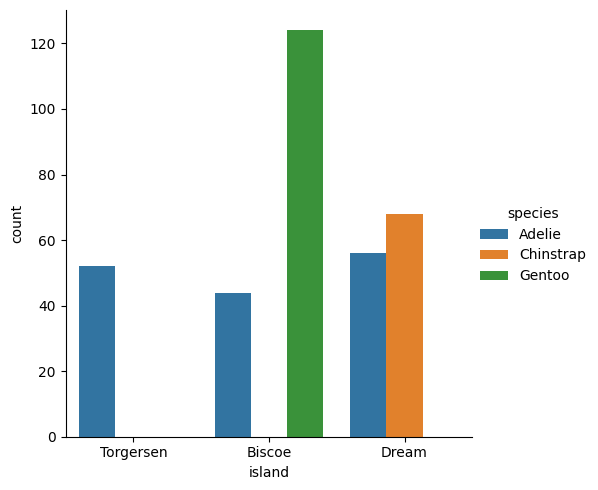

In [17]:
g = sns.catplot(data=penguins, x="island", hue="species", kind="count")

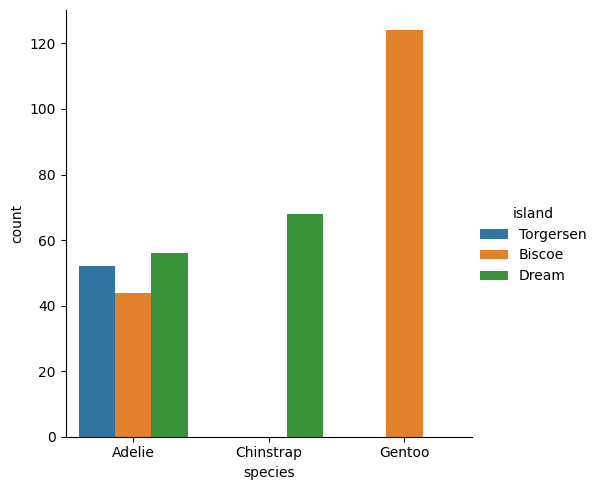

In [39]:
g = sns.catplot(data=penguins, x="species", hue="island", kind="count")


<b>Conclusioni</b>: mentre la specie Adelie sembra equamente distribuita tra le isole, la specie Chinstrap è presente solo in Biscoe Island e la specie Gentoo solo nell'isola Dream


## Rappresentare con un opportuno grafico le relazioni tra le variabili species e il sesso

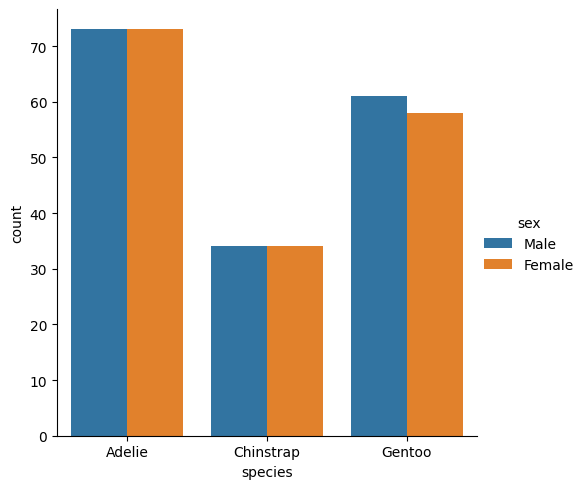

In [40]:
g = sns.catplot(data=penguins, x="species", hue="sex", kind="count")


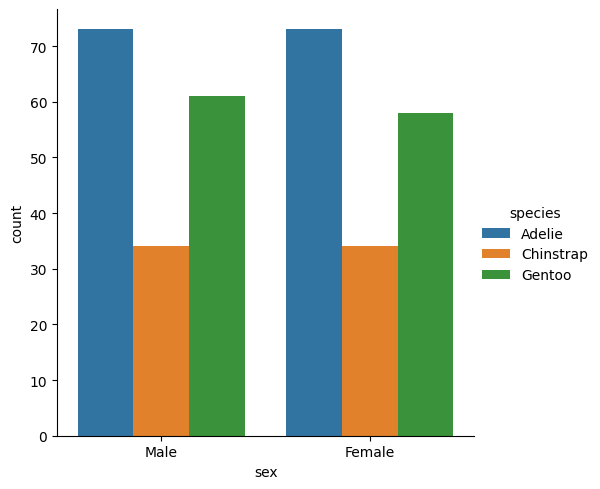

In [24]:
g = sns.catplot(data=penguins, x="sex", hue="species", kind="count")

<b>Conclusione</b>: 
I generi sono sostanzialmente equidistribuiti tra la specie ad eccezione di Gentoo dove si vede una lieve maggioranza di maschi. Di ogni specie è presente praticamente lo stesso numero di maschi e femmine. Il sesso non sembra dunque una variabile significativa per predire la specie, almeno considerata singolarmente (potrebbe diventare significativa se abbinata ad altre variabili).

## Rappresentare le variabili numeriche per individuare outlier e correlazioni

In [31]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

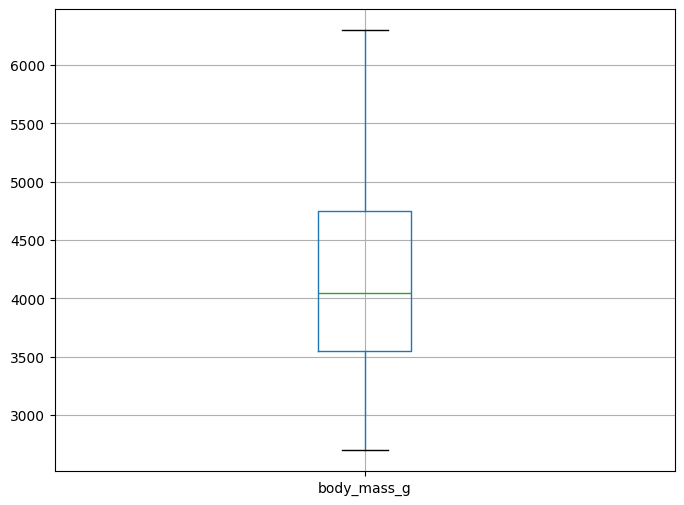

In [30]:
g = penguins.boxplot(column = ["body_mass_g"], figsize = (8,6))

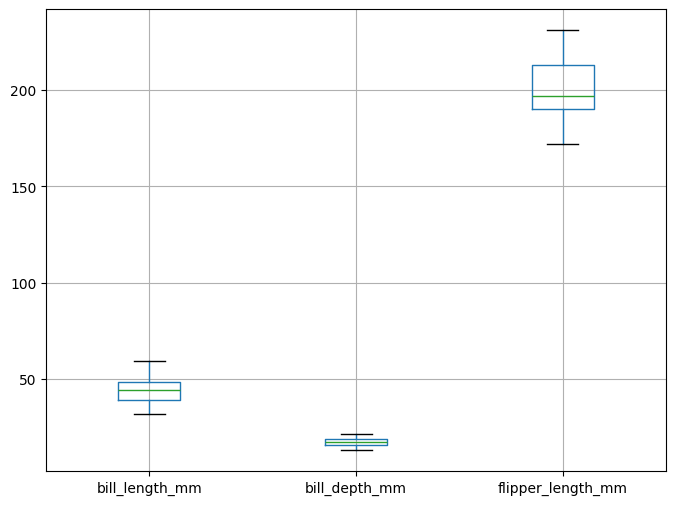

In [29]:
g = penguins.boxplot(column = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"], figsize = (8,6))

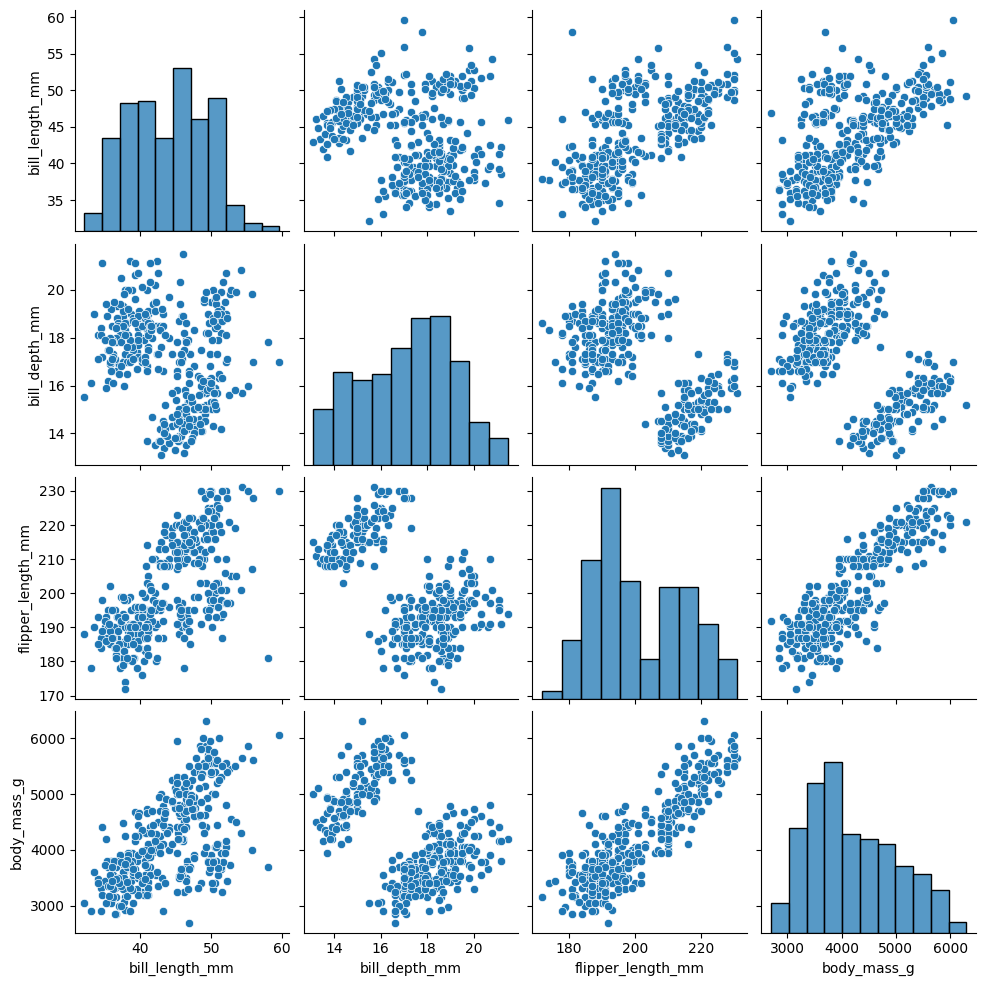

In [42]:
g = sns.pairplot(data=penguins[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]])

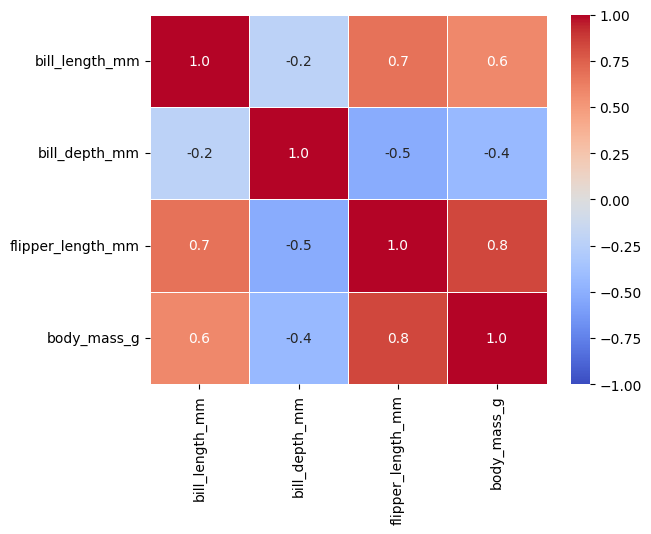

In [43]:
g = sns.heatmap(data = penguins.corr(numeric_only=True, method="spearman"), vmin=-1, vmax=1, annot=True, fmt=".1f", linewidth=.5, cmap='coolwarm')
#g = sns.heatmap(data = penguins.corr(numeric_only=True), vmin=-1, vmax=1, annot=True, fmt=".1f", linewidth=.5)

<b>Conclusioni:</b> non sembrano esserci outlier
La matrice di correlazione e i box plot mostrano una forte correlazione positiva tra :

    le variabili flipper_length_mm e body_mass_g (lunghezza della pinna e massa corporea)
    leggermente meno accentuata tra flipper_length_mm e bill_length_mm (lunghezza della pinna e lunghezza del becco)

Si potrebbe pensare di effettuare dei test senza la variabile flipper_length_mm. Notiamo invece che non c'è correlazione tra lunghezza e profondità del becco (bill_length_mm e bill_depth_mm)


## Rappresentare con un opportuno grafico le relazioni tra le variabili species e la lunghezza del becco

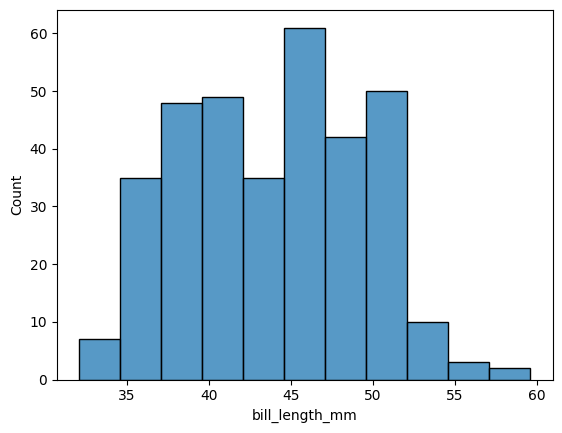

In [32]:
g = sns.histplot(data=penguins, x="bill_length_mm")

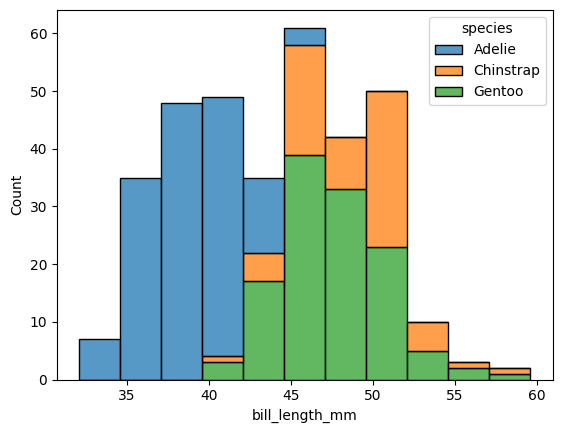

In [33]:
g = sns.histplot(data=penguins, x="bill_length_mm", hue="species", multiple="stack")

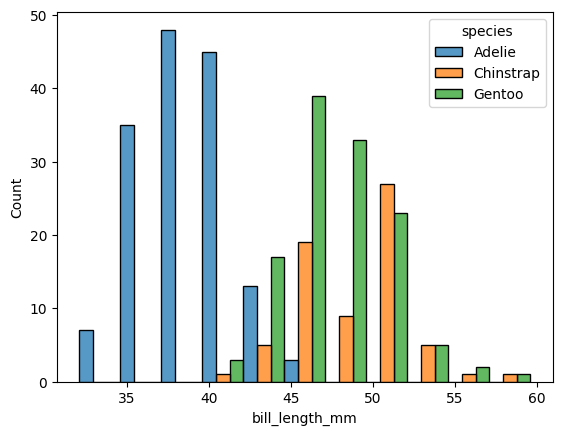

In [34]:
g = sns.histplot(data=penguins, x="bill_length_mm", hue="species", multiple="dodge"    )

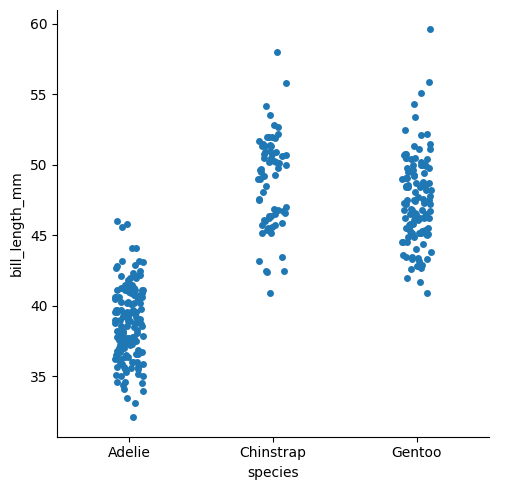

In [44]:
g = sns.catplot(data=penguins, x="species", y="bill_length_mm")

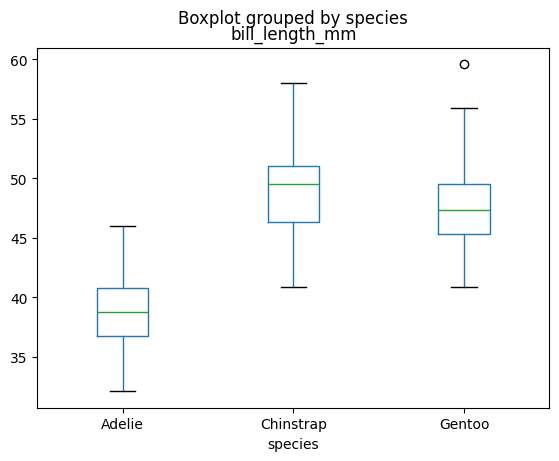

In [45]:
g = penguins.boxplot(by ='species', column =['bill_length_mm'], grid = False)

<b>Conclusioni:</b> dal primo grafico si possono scorgere tre picchi. Dai successivi si può notare che la specie Adelie ha una distribuzione del becco verso valori inferiori, la specie Gentoo su valori intermedi e la specie Chistrap su valori più grandi.
Questa informazione è molto importante in quanto può essere combinata a quanto già visto riguardo la relazione tra specie e isola! Chinstrap e Gentoo infatti vivono su isole diverse, all'interno della stessa isola convivono solo con Adelie e tra loro possono essere riconosciuti abbastanza bene dalla lunghezza del becco


## Rappresentare con un opportuno grafico le relazioni tra le variabili species e la profondità del becco

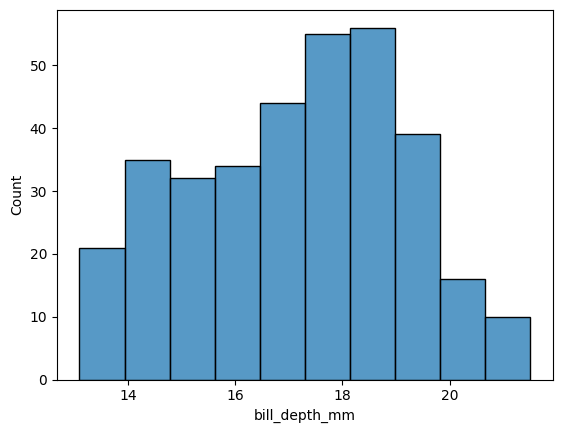

In [35]:
g = sns.histplot(data=penguins, x="bill_depth_mm")

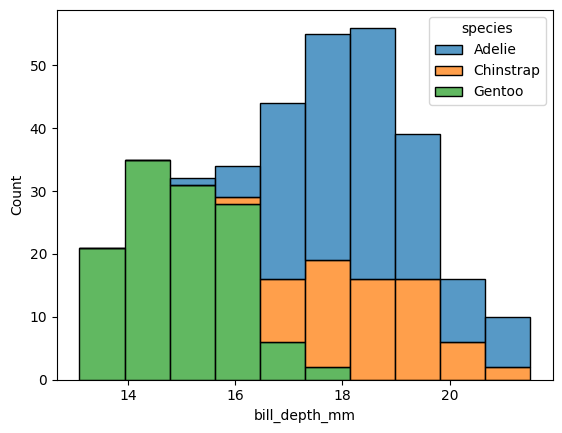

In [36]:
g = sns.histplot(data=penguins, x="bill_depth_mm", hue="species", multiple="stack")

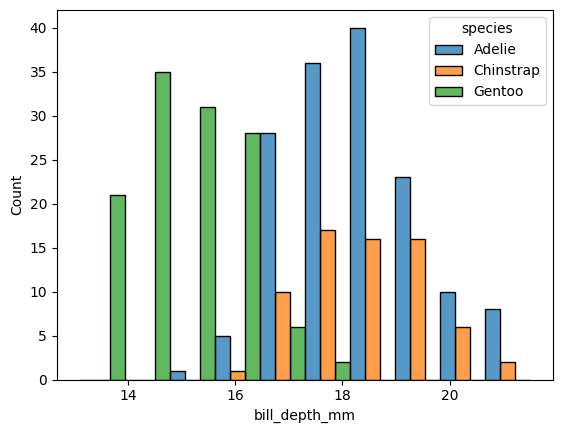

In [48]:
g = sns.histplot(data=penguins, x="bill_depth_mm", hue="species", multiple="dodge")

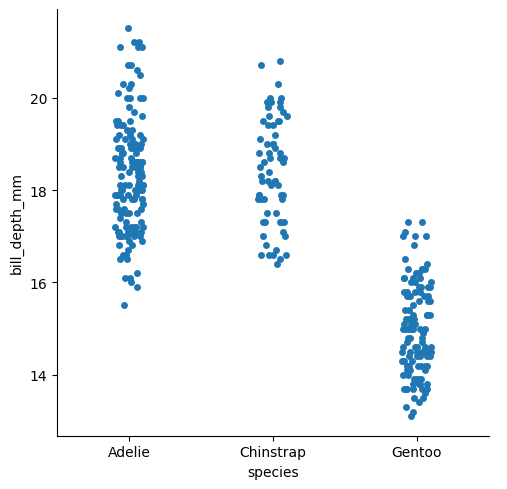

In [46]:
g = sns.catplot(data=penguins, x="species", y="bill_depth_mm")

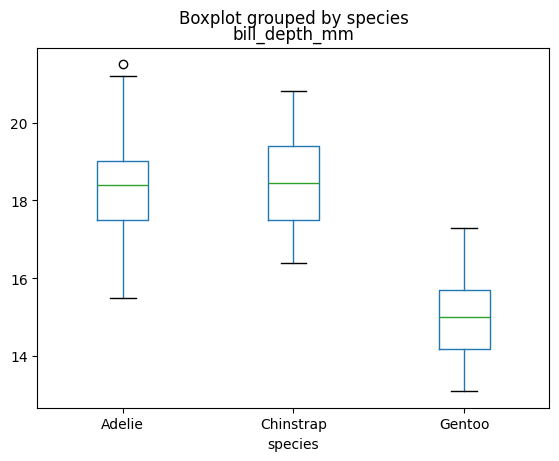

In [47]:
g = penguins.boxplot(by ='species', column =['bill_depth_mm'], grid = False)

<b>Conclusioni:</b> dal primo grafico si notano due picchi, nel secondo e nel terzo si può notare che la specie Gentoo ha una distribuzione su valori più bassi mentre le altre due specie su valori più elevati di profondità del becco.

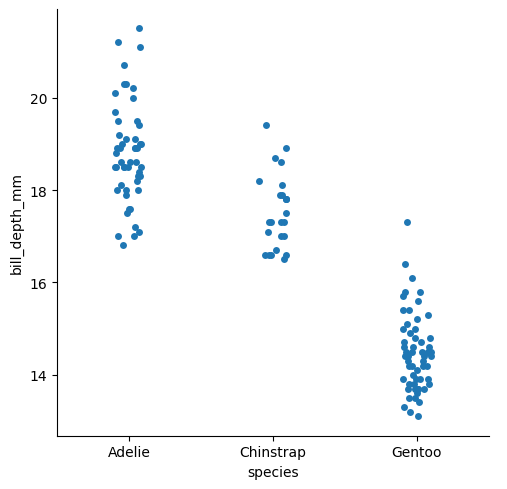

In [49]:
g = sns.catplot(data=penguins.query("bill_length_mm >= 40 and bill_length_mm <=47"), x="species", y="bill_depth_mm")

<b>Conclusioni:</b> Sembra quindi che Gentoo si distingua per una minore profondità del becco, Adelie per una minore lunghezza del becco e, anche laddove si sovrappongono per lunghezza becco (tra 40 e 47 mm), la profondità del becco è funzionale alla loro distinzione.
Profondità e lunghezza del becco possono essere feature utili assieme all'isola in cui vivono le specie per identificare gli esemplari.